In [2]:
import torch
import matplotlib.pyplot as plt
import numpy as np

from mpl_toolkits import mplot3d

In [3]:
class plot_error_surfaces(object):
    def __init__(self, w_range, b_range, X, Y, n_samples = 30, go = True):
        W = np.linspace(-w_range, w_range, n_samples)
        B = np.linspace(-b_range, b_range, n_samples)
        w, b = np.meshgrid(W, B)
        Z = np.zeros((30, 30))
        count1 = 0
        self.y = Y.numpy()
        self.x = X.numpy()
        for w1, b1 in zip(w, b):
            count2 = 0
            for w2, b2 in zip(w1, b1):
                Z[count1, count2] = np.mean((self.y - w2 * self.x + b2) ** 2)
                count2 += 1
            count1 += 1
        self.Z = Z
        self.w = w
        self.b = b
        self.W = []
        self.B = []
        self.LOSS = []
        self.n = 0
        if go == True:
            plt.figure()
            plt.figure(figsize = (7.5, 5))
            plt.axes(projection = '3d').plot_surface(self.w, self.b, self.Z, rstride = 1, cstride = 1,cmap = 'viridis', edgecolor = 'none')
            plt.title('Loss Surface')
            plt.xlabel('w')
            plt.ylabel('b')
            plt.show()
            plt.figure()
            plt.title('Loss Surface Contour')
            plt.xlabel('w')
            plt.ylabel('b')
            plt.contour(self.w, self.b, self.Z)
            plt.show()

    def set_para_loss(self, W, B, loss):
        self.n = self.n + 1
        self.W.append(W)
        self.B.append(B)
        self.LOSS.append(loss)

    def final_plot(self):
        ax = plt.axes(projection = '3d')
        ax.plot_wireframe(self.w, self.b, self.Z)
        ax.scatter(self.W, self.B, self.LOSS, c = 'r', marker = 'x', s = 200, alpha = 1)
        plt.figure()
        plt.contour(self.w, self.b, self.Z)
        plt.scatter(self.W, self.B, c = 'r', marker = 'x')
        plt.xlabel('w')
        plt.ylabel('b')
        plt.show()

    def plot_ps(self):
        plt.subplot(121)
        plt.ylim
        plt.plot(self.x, self.y, 'ro', label = "training points")
        plt.plot(self.x, self.W[-1] * self.x + self.B[-1], label = "estimated line")
        plt.xlabel('x')
        plt.ylabel('y')
        plt.ylim((-10, 15))
        plt.title('Data Space Iteration: ' + str(self.n))
        plt.subplot(122)
        plt.contour(self.w, self.b, self.Z)
        plt.scatter(self.W, self.B, c = 'r', marker = 'x')
        plt.title('Loss Surface Contour Iteration' + str(self.n))
        plt.xlabel('w')
        plt.ylabel('b')
        plt.show()

In [4]:
torch.manual_seed(1)
X = torch.arange(-3, 3, 0.1).view(-1, 1)
f = 1 * X - 1
y = f + 0.1 * torch.randn(X.size())

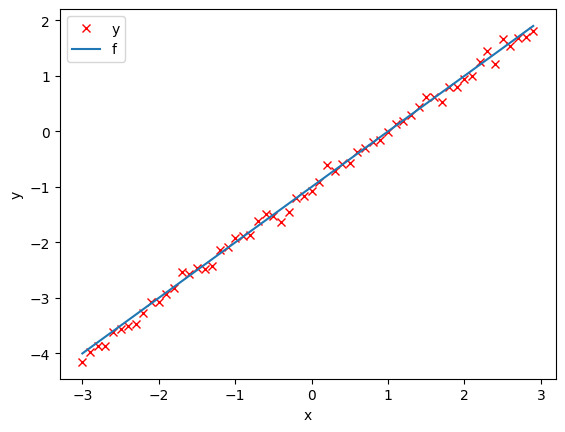

In [13]:
plt.plot(X.numpy(), y.numpy(), "rx", label='y')
plt.plot(X.numpy(), f.numpy(), label="f")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show();

<Figure size 640x480 with 0 Axes>

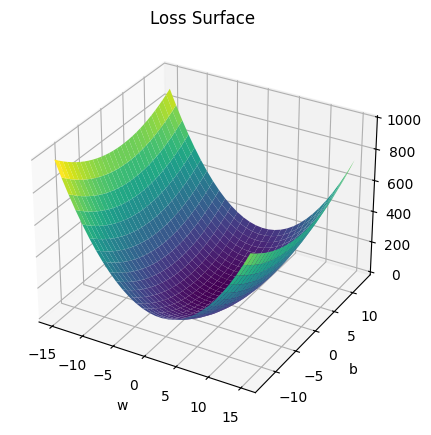

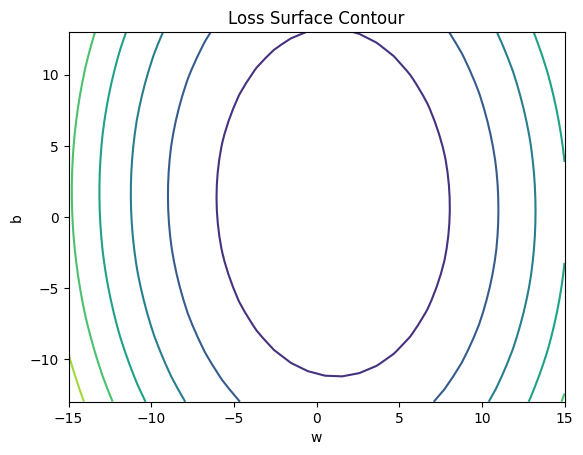

In [14]:
def forward(x):
    return w * x + b

def criterion(yhat, y):
    return torch.mean((yhat - y) **2)

get_surfaces = plot_error_surfaces(15, 13, X, y, 30)

In [34]:
w = torch.tensor(-15.0, requires_grad=True)
b = torch.tensor(-10.0, requires_grad=True)
lr = 0.1
LOSS_BGD = [] # storing loss for each iteration

In [35]:
def train_model(iter):
    for epoch in range(iter):
        yhat = forward(X)
        loss = criterion(yhat, y)

        get_surfaces.set_para_loss(w.data.tolist(), b.data.tolist(), loss.tolist())

        get_surfaces.plot_ps()

        LOSS_BGD.append(loss)

        loss.backward()

        w.data = w.data - lr * w.grad.data
        b.data = b.data - lr * b.grad.data

        w.grad.data.zero_()
        b.grad.data.zero_()

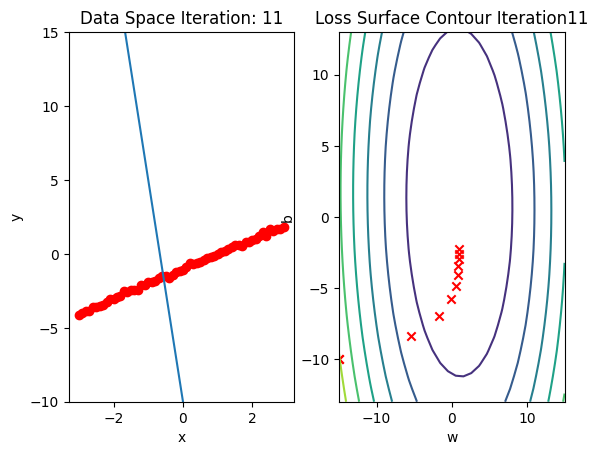

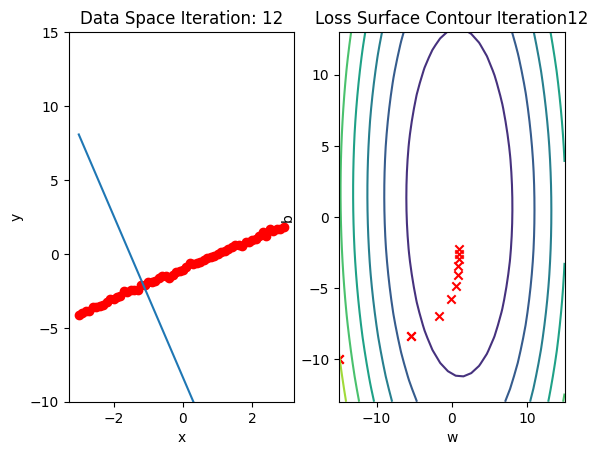

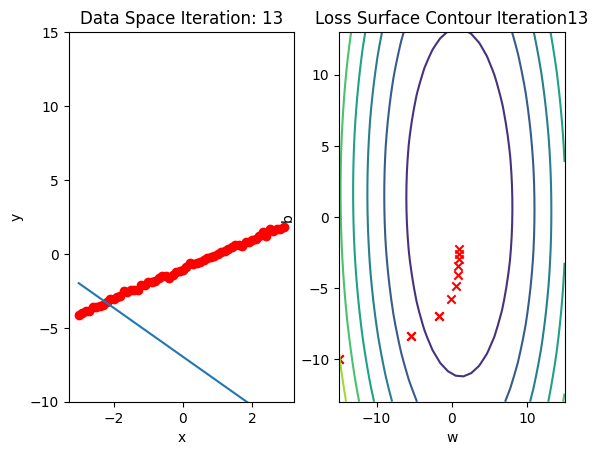

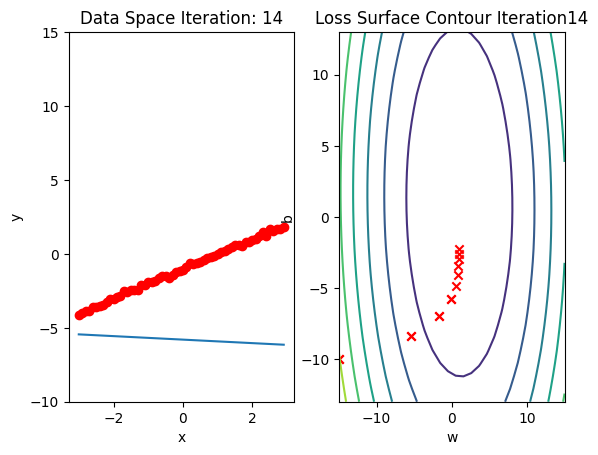

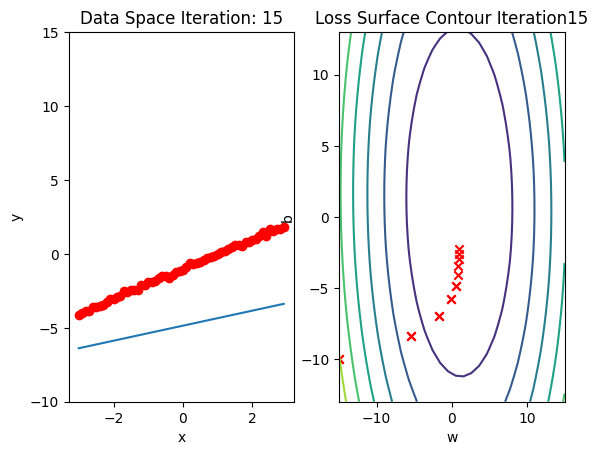

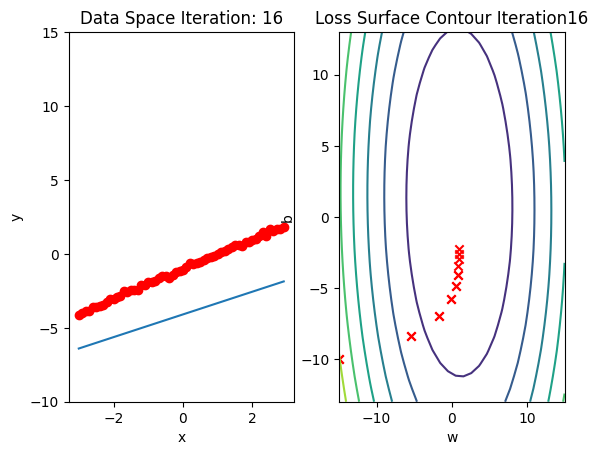

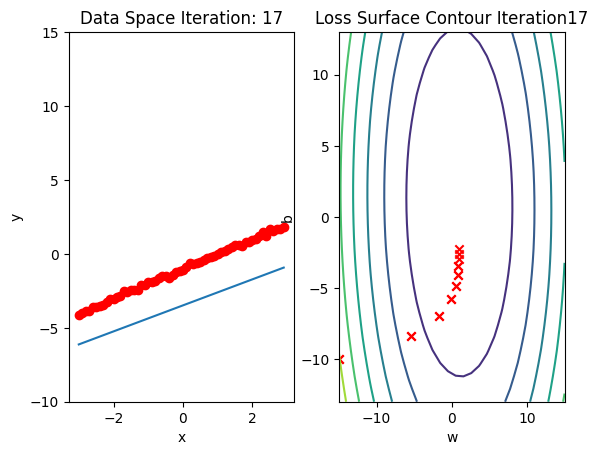

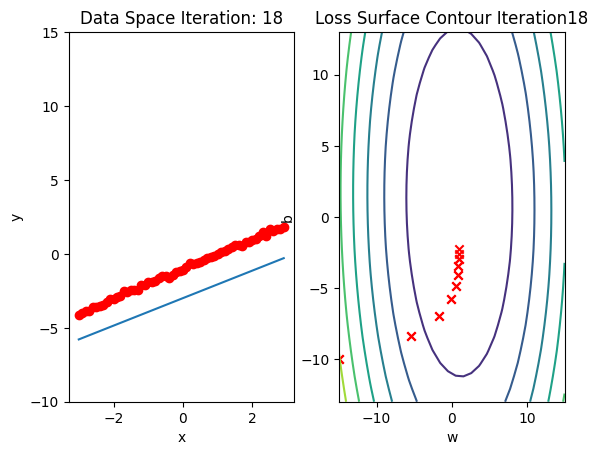

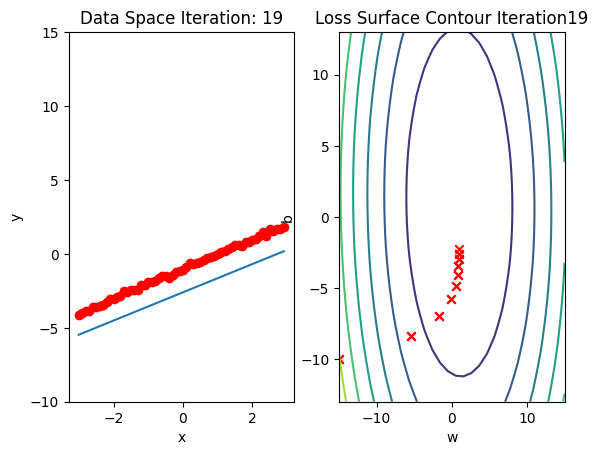

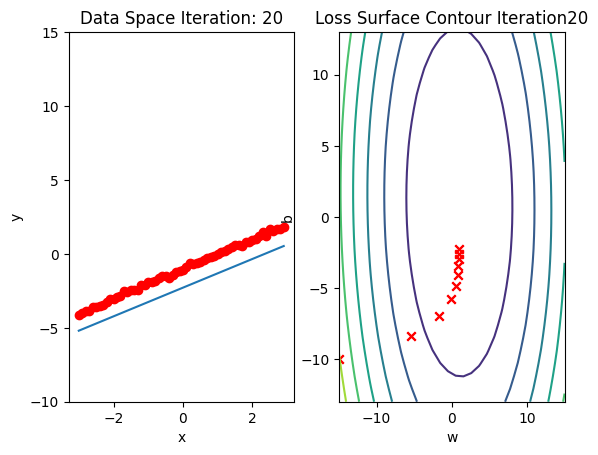

In [36]:
train_model(10)

In [37]:
get_surface = plot_error_surfaces(15, 13, X, y, 30, go = False)

In [42]:
LOSS_SGD = []
w = torch.tensor(-15.0, requires_grad = True)
b = torch.tensor(-10.0, requires_grad = True)

def train_model_SGD(iter, y):

    # Loop
    for epoch in range(iter):

        Yhat = forward(X)

        LOSS_SGD.append(criterion(Yhat, y).tolist())

        for x_, Y in zip(X, y):

            yhat = forward(x_)

            loss = criterion(yhat, Y)


            get_surface.set_para_loss(w.data.tolist(), b.data.tolist(), loss.tolist())


            loss.backward()

            # update parameters slope and bias
            w.data = w.data - lr * w.grad.data
            b.data = b.data - lr * b.grad.data


            w.grad.data.zero_()
            b.grad.data.zero_()

        get_surface.plot_ps()

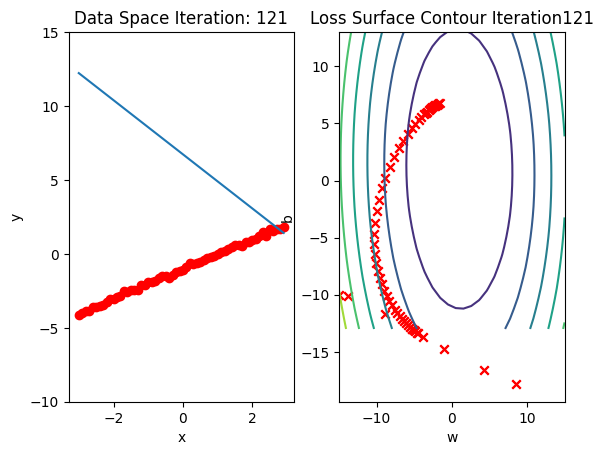

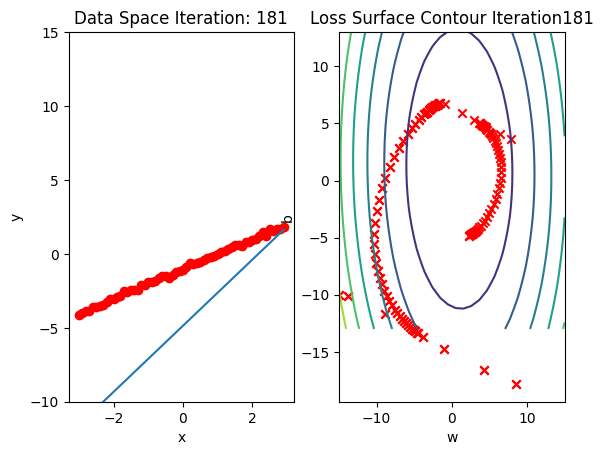

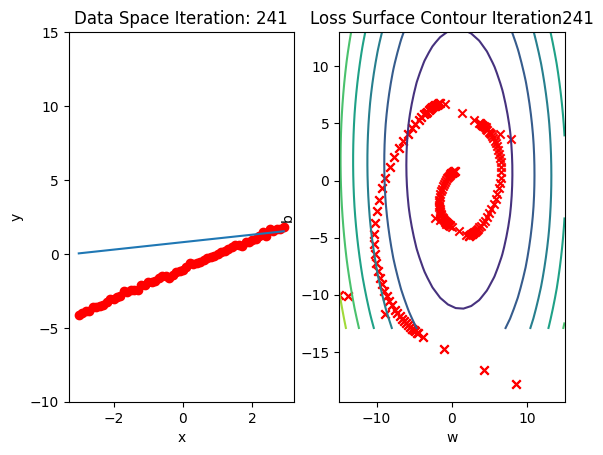

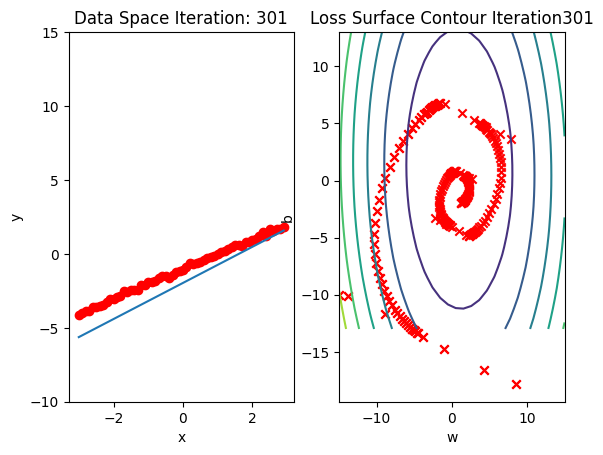

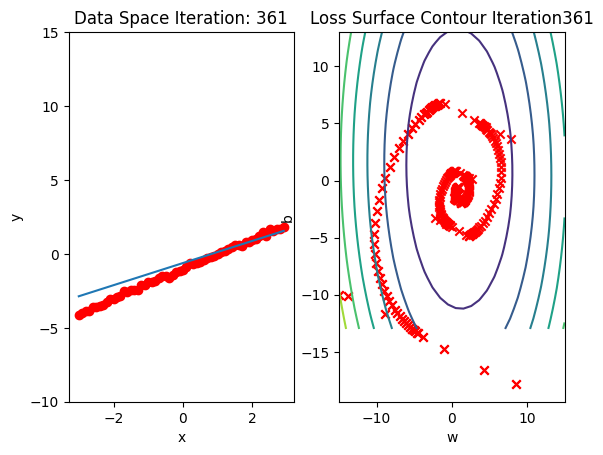

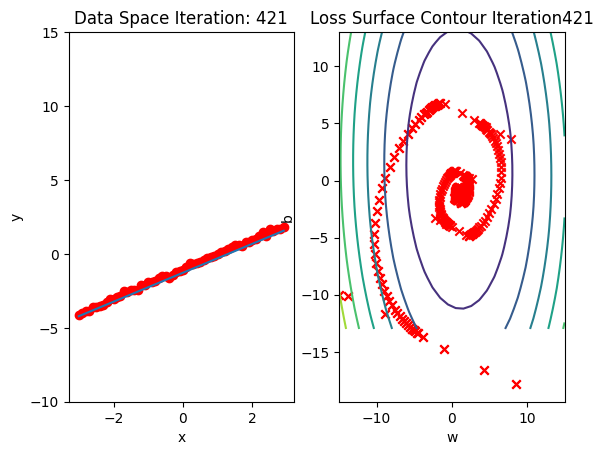

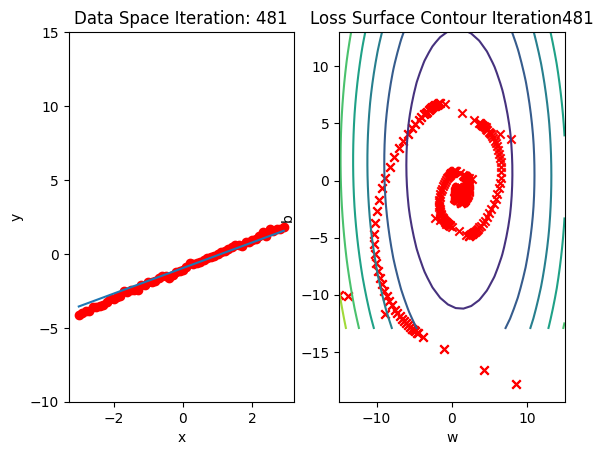

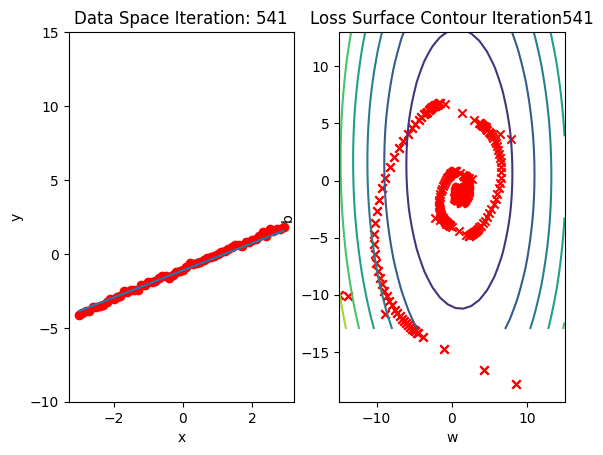

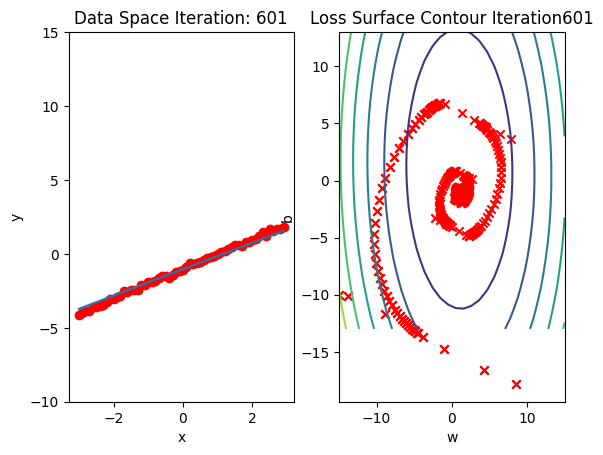

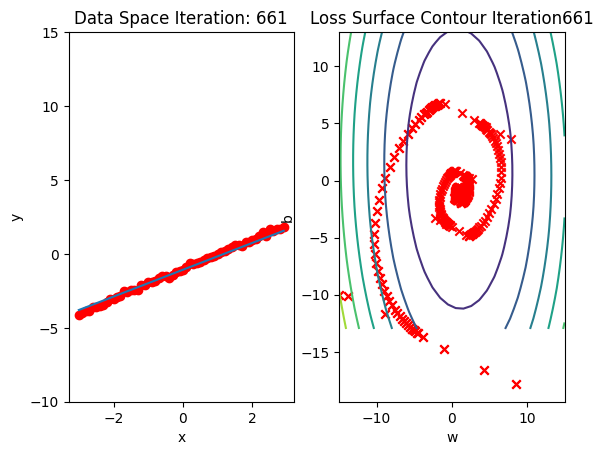

In [43]:
train_model_SGD(10, y)

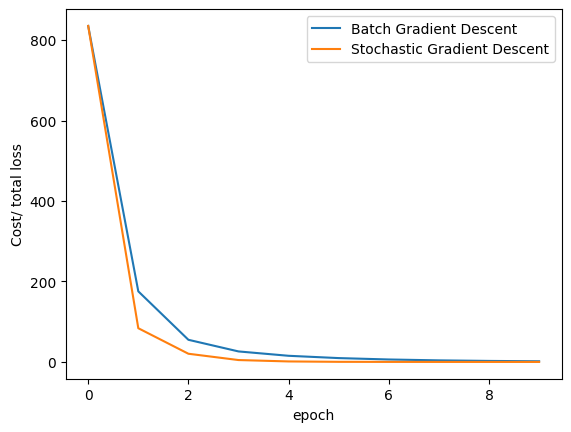

In [44]:
LOSS_BGD= [ loss.detach().numpy() for loss in LOSS_BGD]
plt.plot(LOSS_BGD,label = "Batch Gradient Descent")
plt.plot(LOSS_SGD,label = "Stochastic Gradient Descent")
plt.xlabel('epoch')
plt.ylabel('Cost/ total loss')
plt.legend()
plt.show()

In [45]:
from torch.utils.data import Dataset, DataLoader

class Data(Dataset):
    def __init__(self):
        self.x = torch.arange(-3, 3, 0.1).view(-1, 1)
        self.y = 1 * self.x - 1
        self.len = self.x.shape[0]

    def __getitem__(self, index):
        return self.x[index], self.y[index]

    def __len__(self):
        return self.len

In [46]:
dataset = Data()
len(dataset)

60

In [51]:
X, y = dataset[0]
print(x)
print(y)

tensor([[-3.0000],
        [-2.9000],
        [-2.8000]])
tensor([-4.])


In [52]:
X, y = dataset[0:3]
print(x)
print(y)

tensor([[-3.0000],
        [-2.9000],
        [-2.8000]])
tensor([[-4.0000],
        [-3.9000],
        [-3.8000]])


In [53]:
get_surface = plot_error_surfaces(15, 13, X, y, 30, go = False)

In [54]:
trainloader = DataLoader(dataset=dataset, batch_size=1)

In [55]:
w = torch.tensor(-15.0,requires_grad=True)
b = torch.tensor(-10.0,requires_grad=True)
LOSS_Loader = []

def train_model_DataLoader(epochs, y):

    # Loop
    for epoch in range(epochs):

        # SGD is an approximation of out true total loss/cost, in this line of code we calculate our true loss/cost and store it
        Yhat = forward(X)

        # store the loss
        LOSS_Loader.append(criterion(Yhat, y).tolist())

        for x_, y_ in trainloader:

            # make a prediction
            yhat = forward(x_)

            # calculate the loss
            loss = criterion(yhat, y_)

            # Section for plotting
            get_surface.set_para_loss(w.data.tolist(), b.data.tolist(), loss.tolist())

            # Backward pass: compute gradient of the loss with respect to all the learnable parameters
            loss.backward()

            # Updata parameters slope
            w.data = w.data - lr * w.grad.data
            b.data = b.data - lr* b.grad.data

            # Clear gradients
            w.grad.data.zero_()
            b.grad.data.zero_()

        #plot surface and data space after each epoch
        get_surface.plot_ps()

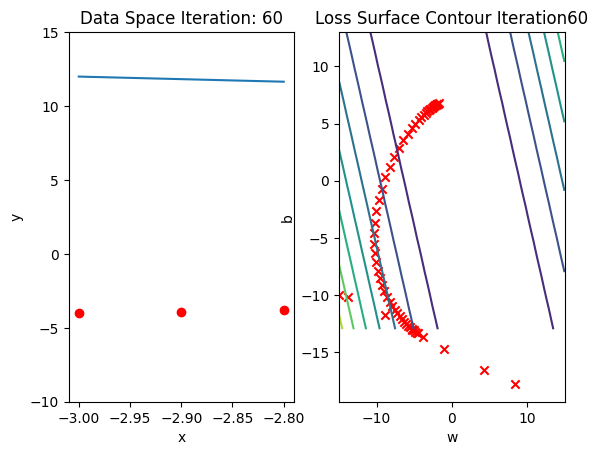

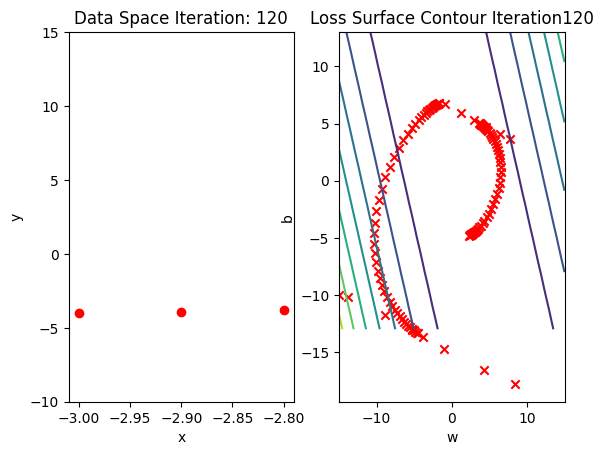

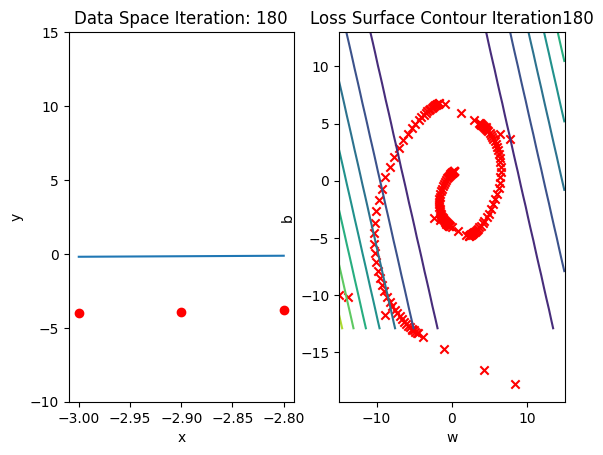

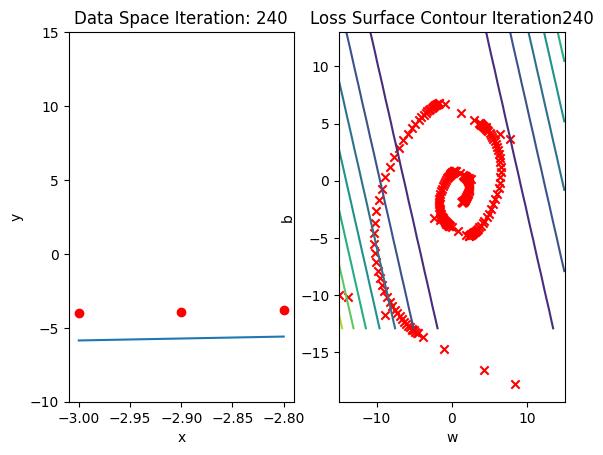

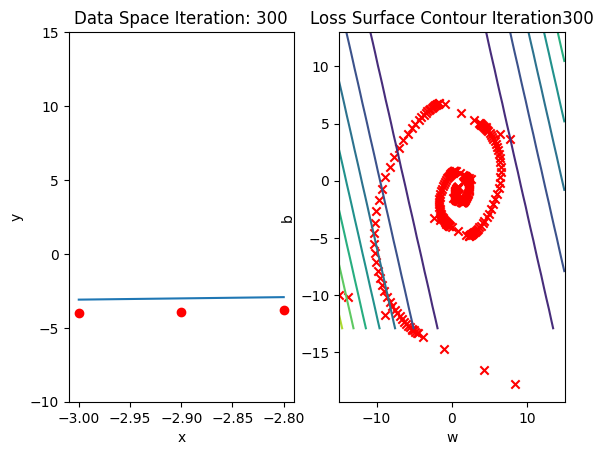

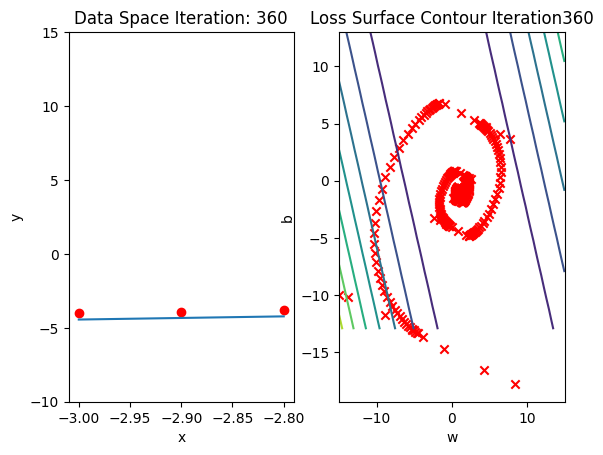

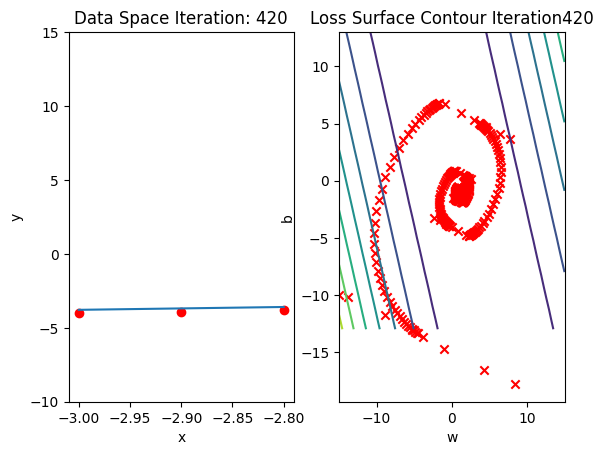

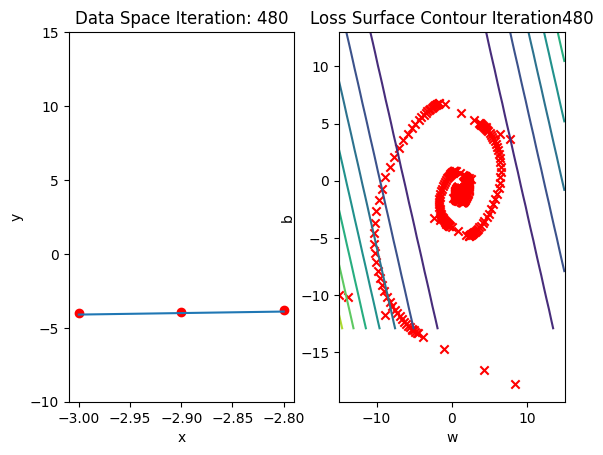

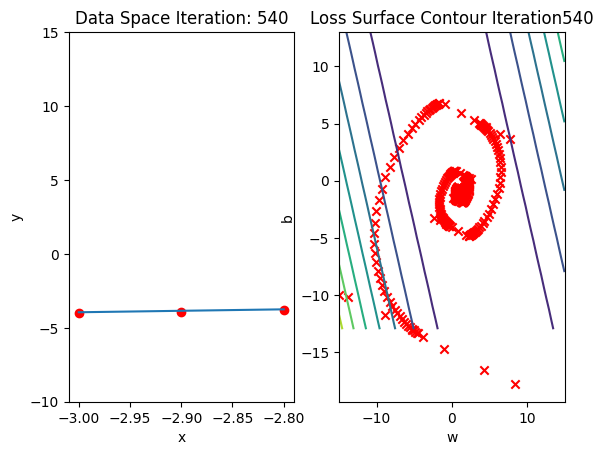

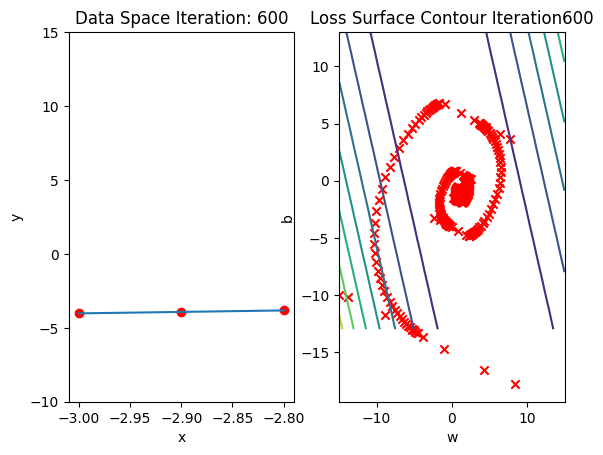

In [57]:
train_model_DataLoader(10, y)

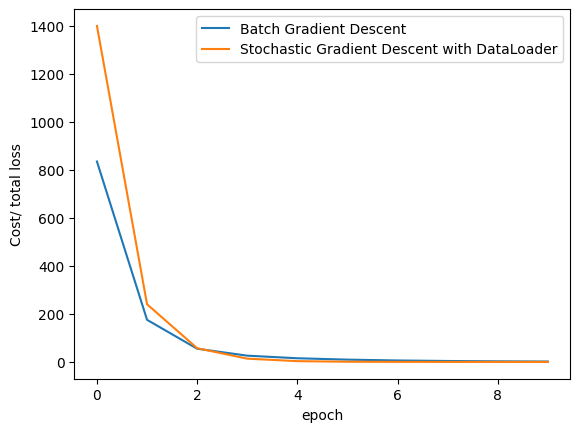

In [58]:
plt.plot(LOSS_BGD,label="Batch Gradient Descent")
plt.plot(LOSS_Loader,label="Stochastic Gradient Descent with DataLoader")
plt.xlabel('epoch')
plt.ylabel('Cost/ total loss')
plt.legend()
plt.show()